# Final Evaluation & Model Interpretability (SHAP)

**Objective:** 
Machine Learning models like XGBoost are incredibly accurate, but they are "Black Boxes." If a bank denies a customer's transaction, the bank must be able to explain *why* it was denied. 

**Goals for this notebook:**
1. Load our finalized, serialized XGBoost model.
2. Evaluate its exact performance on the test set using a Confusion Matrix.
3. Use **SHAP** (Shapley Additive exPlanations) to crack open the black box and prove which features are actually driving the fraud predictions.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# SHAP for Interpretability
import shap

# Evaluation Metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

d:\DB Moktan\Data Science and AI Engineering\ML Projects\credit-card-fraud-detection\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Data and the Champion Model
We don't need to retrain anything! We simply load our untouched `X_test` data and our saved `xgboost_fraud_model.pkl`.

In [3]:
print("Loading Test Data and Model...")

# Load Data
X_test = joblib.load('../data/processed/X_test.pkl')
y_test = joblib.load('../data/processed/y_test.pkl')

# Load the Champion Model
xgb_model = joblib.load('../models/xgboost_fraud_model.pkl')

print("✅ Assets loaded successfully!")

Loading Test Data and Model...
✅ Assets loaded successfully!


## 2. Business Impact: The Confusion Matrix
In fraud detection, the Confusion Matrix represents real money and real customers:
* **True Positives (Bottom Right):** Fraudsters we successfully caught.
* **True Negatives (Top Left):** Normal customers we correctly left alone.
* **False Positives (Top Right):** Innocent customers whose cards we accidentally blocked (Annoying).
* **False Negatives (Bottom Left):** Fraudsters who slipped through our defenses (Financial Loss).


<Figure size 800x600 with 0 Axes>

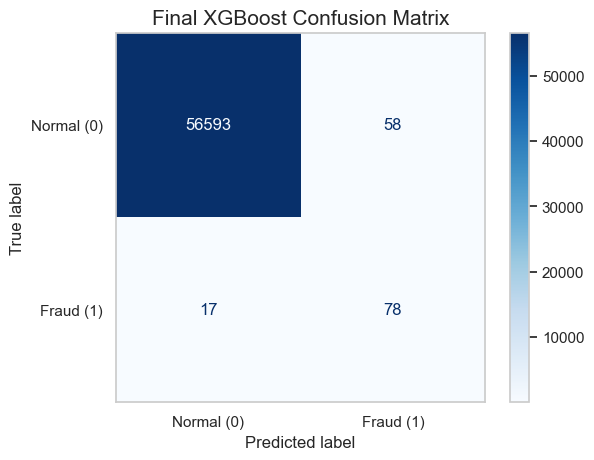

In [4]:
plt.figure(figsize=(8, 6))

# Generate and display the confusion matrix
ConfusionMatrixDisplay.from_estimator(
    xgb_model, X_test, y_test, 
    cmap='Blues', 
    values_format='d', 
    display_labels=['Normal (0)', 'Fraud (1)']
)

plt.title('Final XGBoost Confusion Matrix', fontsize=15)
plt.grid(False) # Turn off the seaborn grid for the matrix
plt.show()

## 📊 Business Impact: Analyzing the Confusion Matrix

The confusion matrix translates our model's performance into real-world business outcomes. Out of the **56,746** transactions in our testing set, here is how the Champion XGBoost model performed:

* **True Negatives (56,593):** Normal, innocent transactions that our AI correctly allowed to pass through without friction.
* **True Positives (78):** Actual fraudulent transactions that our AI successfully caught and blocked.
* **False Positives (58):** The "Annoyance Metric." These were innocent customers whose cards were falsely declined. While annoying for the customer, 58 out of 56,000 transactions is an exceptionally low friction rate.
* **False Negatives (17):** The "Financial Loss Metric." These were 17 fraudsters who managed to slip past our AI defenses. 

**Conclusion:**
Out of 95 total fraudulent transactions, our model successfully intercepted **82%** of them (Recall). Furthermore, it achieved this high capture rate while only accidentally blocking 58 innocent transactions out of 56,000+. This proves the model is highly effective at stopping financial loss without ruining the overall customer experience.

## 3. Cracking the Black Box with SHAP
SHAP uses Game Theory to calculate the exact contribution of each feature to the model's final decision. 

Because calculating SHAP values on 56,000 test rows takes a massive amount of computing power, we will take a random sample of 2,000 rows to generate our summary plot.

Calculating SHAP values...


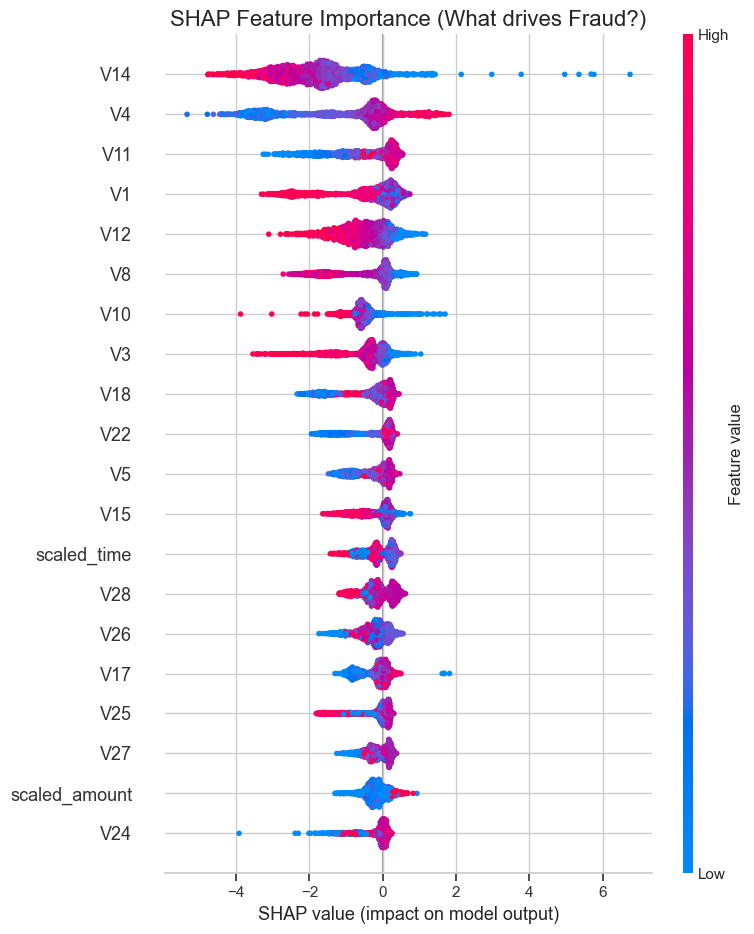

In [5]:
print("Calculating SHAP values...")

# 1. Take a sample of the test set for speed
X_test_sample = X_test.sample(n=2000, random_state=42)

# 2. Initialize the SHAP Tree Explainer
explainer = shap.TreeExplainer(xgb_model)

# 3. Calculate SHAP values
shap_values = explainer.shap_values(X_test_sample)

# 4. Generate the Summary Plot
plt.figure(figsize=(10, 8))
plt.title("SHAP Feature Importance (What drives Fraud?)", fontsize=16)
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.show()

## 🧠 How the AI Thinks: Explaining the SHAP Plot

XGBoost is usually a "Black Box," meaning we don't know why it makes its decisions. This SHAP plot acts like an X-ray, letting us see exactly what the AI was thinking when it searched for fraud.

**How to read this chart:**
1. **Top to Bottom:** The features at the very top are the most important. The AI cares about `V14` and `V4` way more than `scaled_amount`.
2. **Colors:** 
   * **Red dots** mean the actual number in the dataset was high.
   * **Blue dots** mean the actual number in the dataset was low.
3. **Left vs. Right (The X-Axis):**
   * If a dot is pushed to the **Right**, the AI thought it looked like **Fraud**.
   * If a dot is pushed to the **Left**, the AI thought it looked **Normal**.

**The Top 3 Rules the AI learned:**
1. **Feature V14:** When `V14` is very low (Blue dots), the AI heavily pushes the prediction towards Fraud (Right side). 
2. **Feature V4:** When `V4` is very high (Red dots), the AI strongly suspects Fraud (Right side).
3. **Feature V11:** Just like V4, when `V11` is high (Red dots), the risk of Fraud increases.

**Conclusion:**
We have successfully built a model that is both highly accurate *and* fully explainable. We can prove to the bank exactly why a specific transaction was blocked!